In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import folium
from folium.plugins import HeatMap
import warnings
warnings.filterwarnings('ignore')

In [2]:
crimes = pd.read_csv('Chicago_Crimes.csv')

In [3]:
crimes

,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,...,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location
0,13439321,JH237424,04/14/2024 12:00:00 AM,040XX S PRAIRIE AVE,0890,THEFT,FROM BUILDING,APARTMENT,False,False,...,3,38.0,06,1178707.0,1878256.0,2024,12/21/2024 03:40:46 PM,41.821236,-87.619921,"(41.821236024, -87.619920712)"
1,13437420,JH234779,04/14/2024 12:00:00 AM,023XX W CERMAK RD,2825,OTHER OFFENSE,HARASSMENT BY TELEPHONE,COMMERCIAL / BUSINESS OFFICE,False,False,...,25,31.0,26,1161210.0,1889347.0,2024,12/21/2024 03:40:46 PM,41.852052,-87.683801,"(41.852051675, -87.683800849)"
2,13428676,JH224478,04/14/2024 12:00:00 AM,043XX W LE MOYNE ST,0917,MOTOR VEHICLE THEFT,"CYCLE, SCOOTER, BIKE WITH VIN",STREET,False,False,...,36,23.0,07,1146960.0,1909501.0,2024,12/21/2024 03:40:46 PM,41.907640,-87.735587,"(41.907640473, -87.735587478)"
3,13429357,JH225293,04/14/2024 12:00:00 AM,039XX W ADAMS ST,143A,WEAPONS VIOLATION,UNLAWFUL POSSESSION - HANDGUN,STREET,True,False,...,28,26.0,15,1150158.0,1898721.0,2024,12/21/2024 03:40:46 PM,41.877997,-87.724121,"(41.877997275, -87.724120826)"
4,13430098,JH226395,04/14/2024 12:00:00 AM,011XX W 112TH PL,0890,THEFT,FROM BUILDING,RESIDENCE,False,False,...,21,75.0,06,1170856.0,1830157.0,2024,12/21/2024 03:40:46 PM,41.689421,-87.650123,"(41.6894214, -87.650123247)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
249118,13805239,JJ217509,04/12/2025 12:00:00 AM,029XX W LOGAN BLVD,2826,OTHER OFFENSE,HARASSMENT BY ELECTRONIC MEANS,APARTMENT,False,False,...,1,22.0,26,1156478.0,1917149.0,2025,04/19/2025 03:41:24 PM,41.928440,-87.700416,"(41.928439867, -87.700415972)"
249119,13804023,JJ215813,04/12/2025 12:00:00 AM,094XX S HARVARD AVE,0430,BATTERY,AGGRAVATED - OTHER DANGEROUS WEAPON,STREET,False,False,...,9,49.0,04B,1175694.0,1842631.0,2025,04/19/2025 03:41:24 PM,41.723545,-87.632040,"(41.723545182, -87.632039508)"
249120,13803926,JJ215943,04/12/2025 12:00:00 AM,084XX S VINCENNES AVE,0486,BATTERY,DOMESTIC BATTERY SIMPLE,APARTMENT,False,True,...,21,71.0,08B,1173850.0,1848976.0,2025,04/19/2025 03:41:24 PM,41.740998,-87.638606,"(41.74099774, -87.638606337)"
249121,13803475,JJ215338,04/12/2025 12:00:00 AM,050XX S ABERDEEN ST,0530,ASSAULT,AGGRAVATED - OTHER DANGEROUS WEAPON,STREET,True,False,...,20,61.0,04A,1169838.0,1871348.0,2025,04/19/2025 03:41:24 PM,41.802477,-87.652657,"(41.802477219, -87.652657244)"


<h2>Cleaning Data</h2>

In [4]:
crimes.isnull().sum()

ID                        0
Case Number               0
Date                      0
Block                     0
IUCR                      0
Primary Type              0
Description               0
Location Description    857
Arrest                    0
Domestic                  0
Beat                      0
District                  0
Ward                      0
Community Area            3
FBI Code                  0
X Coordinate             90
Y Coordinate             90
Year                      0
Updated On                0
Latitude                 90
Longitude                90
Location                 90
dtype: int64

In [5]:
crimes['Location Description'] = crimes['Location Description'].fillna(crimes['Location Description'].mode()[0])
crimes['Community Area'] = crimes['Community Area'].fillna(crimes['Community Area'].mode()[0])
crimes['X Coordinate'] = crimes['X Coordinate'].fillna(crimes['Latitude'].mode()[0])
crimes['Y Coordinate'] = crimes['Y Coordinate'].fillna(crimes['Latitude'].mode()[0])
crimes['Latitude'] = crimes['Latitude'].fillna(crimes['Latitude'].mode()[0])
crimes['Longitude'] = crimes['Longitude'].fillna(crimes['Longitude'].mode()[0])
crimes['Location'] = crimes['Location'].fillna(crimes['Latitude'].mode()[0])

In [6]:
crimes.isnull().sum()

ID                      0
Case Number             0
Date                    0
Block                   0
IUCR                    0
Primary Type            0
Description             0
Location Description    0
Arrest                  0
Domestic                0
Beat                    0
District                0
Ward                    0
Community Area          0
FBI Code                0
X Coordinate            0
Y Coordinate            0
Year                    0
Updated On              0
Latitude                0
Longitude               0
Location                0
dtype: int64

In [7]:
list(crimes.columns)

['ID',
 'Case Number',
 'Date',
 'Block',
 'IUCR',
 'Primary Type',
 'Description',
 'Location Description',
 'Arrest',
 'Domestic',
 'Beat',
 'District',
 'Ward',
 'Community Area',
 'FBI Code',
 'X Coordinate',
 'Y Coordinate',
 'Year',
 'Updated On',
 'Latitude',
 'Longitude',
 'Location']

<h2>Changing Data Types</h2>

In [8]:
crimes.dtypes

ID                        int64
Case Number              object
Date                     object
Block                    object
IUCR                     object
Primary Type             object
Description              object
Location Description     object
Arrest                     bool
Domestic                   bool
Beat                      int64
District                  int64
Ward                      int64
Community Area          float64
FBI Code                 object
X Coordinate            float64
Y Coordinate            float64
Year                      int64
Updated On               object
Latitude                float64
Longitude               float64
Location                 object
dtype: object

In [9]:
crimes['Date'] = crimes['Date'].str.strip()

crimes['Date'] = crimes['Date'].astype('str')

crimes['Date'] = crimes['Date'].str.replace('/', '-')

crimes['Date'] = pd.to_datetime(crimes['Date'], dayfirst=True, errors='coerce')

crimes['Case Number'] = crimes['Case Number'].astype('category')
crimes['Block'] = crimes['Block'].astype('category')
crimes['IUCR'] = crimes['IUCR'].astype('category')
crimes['Primary Type'] = crimes['Primary Type'].astype('category')
crimes['Description'] = crimes['Description'].astype('category')
crimes['Location Description'] = crimes['Location Description'].astype('category')
crimes['FBI Code'] = crimes['FBI Code'].astype('category')
crimes['Updated On'] = crimes['Updated On'].astype('category')
crimes['Location'] = crimes['Location'].astype('category')

In [10]:
crimes['Year'] = crimes['Date'].dt.year
crimes['Month'] = crimes['Date'].dt.month
crimes['Day'] = crimes['Date'].dt.day
crimes['DayOfWeek'] = crimes['Date'].dt.dayofweek

In [11]:
crimes.dtypes

ID                               int64
Case Number                   category
Date                    datetime64[ns]
Block                         category
IUCR                          category
Primary Type                  category
Description                   category
Location Description          category
Arrest                            bool
Domestic                          bool
Beat                             int64
District                         int64
Ward                             int64
Community Area                 float64
FBI Code                      category
X Coordinate                   float64
Y Coordinate                   float64
Year                             int32
Updated On                    category
Latitude                       float64
Longitude                      float64
Location                      category
Month                            int32
Day                              int32
DayOfWeek                        int32
dtype: object

In [12]:
crimes1 = crimes[crimes['Primary Type'] == 'BATTERY']

crimes1 = crimes1.groupby(['Latitude','Longitude']).size().reset_index(name='crime_count')

x = folium.Map(location=[41.7958,-87.6232], zoom_start=10)

HeatMap(crimes1).add_to(x)
x

<h2>INSIGHTS</h2>
<h3>1. The heatmap shows that battery incidents are heavily concentrated in the downtown and south-side regions, suggesting these areas experience the highest levels of violent encounters.</h3>
<h3>2. The hotspots align with areas of higher population density and activity, such as business districts and transit hubs, where interactions between large numbers of people may increase the likelihood of conflict..</h3>
<h3>3. Areas toward the outskirts of Chicago and suburban neighborhoods show far fewer battery cases, indicating these regions are relatively safer in terms of physical assault crimes</h3>

In [13]:
crimes2 = crimes[crimes['Ward']== 27]

crimesLD = crimes2[crimes2['Primary Type'] == 'THEFT']

locations  = list(zip(crimesLD['Latitude'],crimesLD['Longitude']))

x = folium.Map(location=[crimesLD['Latitude'].mean(), crimesLD['Longitude'].mean()], zoom_start=10)

HeatMap(locations).add_to(x)
x

<h2>INSIGHTS</h2>
<h3>4. Theft incidents are heavily clustered around central business and commercial districts, suggesting high crime risks in busy urban areas.</h3>
<h3>5. The density of theft crimes overlaps with shopping areas, offices, and nightlife zones, highlighting that theft is more common where people frequently gather and transact.</h3>
<h3>6. Areas further from the city center, especially more residential zones of Ward 27, show significantly fewer theft cases, implying that theft is less prevalent in low-foot-traffic neighborhoods.</h3>

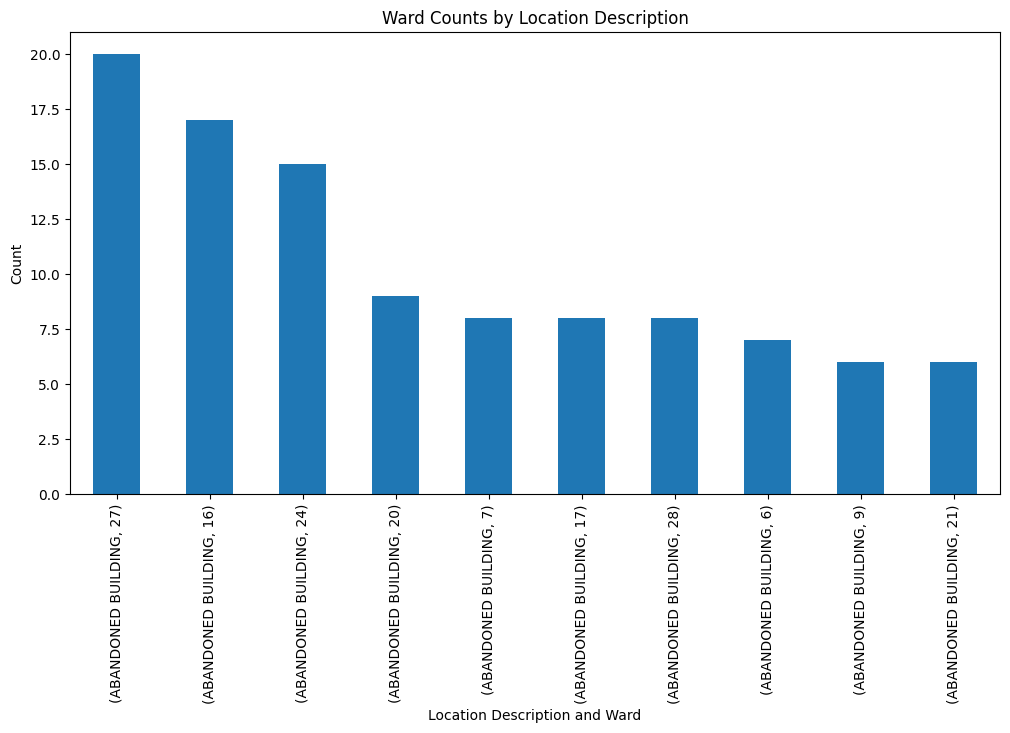

In [14]:
x = crimes.groupby(['Location Description'])['Ward'].value_counts().head(10)
x.plot(kind='bar', figsize=(12, 6))
plt.title('Ward Counts by Location Description')
plt.xlabel('Location Description and Ward')
plt.ylabel('Count')
plt.show()

<h2>INSIGHTS</h2>
<h3>7. Ward 27 has the highest concentration of crimes in abandoned buildings, indicating that this ward faces significant issues with vacant structures becoming hotspots for criminal activity.</h3>
<h3>8. Wards 10 and 24 also show elevated crime levels in abandoned buildings, suggesting that crime in such neglected spaces is not isolated to one area but is a recurring urban issue.</h3>
<h3>9. Other wards (like 6, 9, 21) report fewer incidents, but still notable – highlighting that abandoned buildings across Chicago, regardless of location, tend to attract criminal behavior, though at varying intensities.</h3>

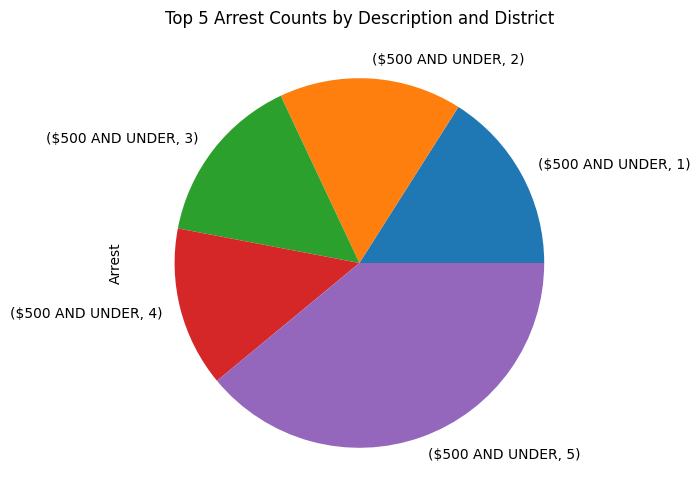

In [15]:
x = crimes.groupby(['Description', 'District'])['Arrest'].sum().head(5)
x.plot(kind='pie', figsize=(12, 6))
plt.title('Top 5 Arrest Counts by Description and District')
plt.show()

<h2>INSIGHTS</h2>
<h3>10. Theft under $500 dominates arrests across districts – showing that small-scale property crimes are a major driver of police activity in Chicago.</h3>
<h3>11. District 5 accounts for the largest share of arrests – indicating that this area experiences more frequent enforcement or higher incidence of petty theft compared to other districts.</h3>
<h3>12. Arrests are relatively balanced across Districts 1–4, but still significant – suggesting that low-value theft is a citywide issue, not confined to just one region.</h3>

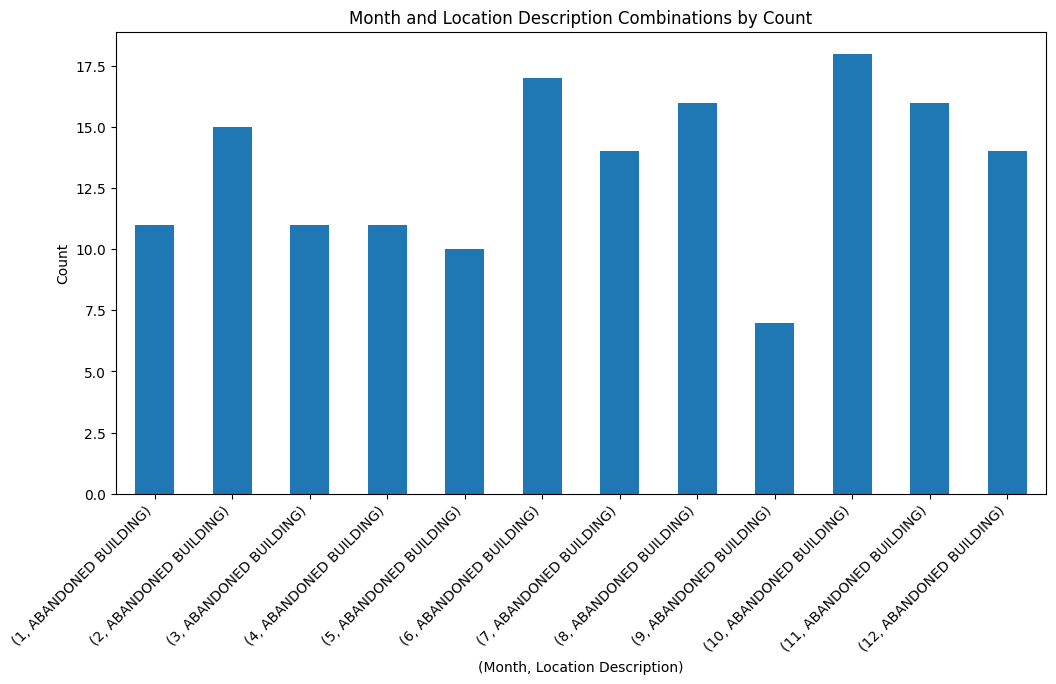

In [16]:
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

x = crimes.groupby(['Month', 'Location Description']).size().sort_index(level=0)

x = x.groupby(level=0).head(1)
x.plot(kind='bar', figsize=(12, 6))

plt.title('Month and Location Description Combinations by Count')
plt.xlabel('(Month, Location Description)')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.show()

<h2>INSIGHTS</h2>
<h3>13. November shows the highest count of crimes in abandoned buildings – suggesting a seasonal spike in activity, possibly linked to colder weather or holiday-related factors.</h3>
<h3>14.March and July also record relatively high incidents – indicating that abandoned building crimes are not limited to one season but occur throughout the year with varying peaks.</h3>
<h3>15. February has the lowest count of crimes in abandoned buildings – highlighting a possible seasonal dip, which may be influenced by weather conditions or reduced public activity.</h3>

In [17]:
crimes3 = crimes[crimes['Primary Type'] == 'ARSON']

crimes3 = crimes3.groupby(['Latitude','Longitude']).size().reset_index(name='crime_count')

x = folium.Map(location=[41.7958,-87.6232], zoom_start=10)

HeatMap(crimes3).add_to(x)
x

<h2>INSIGHTS</h2>
<h3>16. South and West Chicago show higher arson activity – with dense clusters of incidents concentrated in these regions, suggesting localized arson problems.</h3>
<h3>17. Scattered hotspots appear across the city – indicating that while arson is less common than theft or battery, it still occurs across multiple neighborhoods rather than being confined to one area.</h3>
<h3>18. Industrial and residential overlap areas are more affected – hotspots are visible near mixed-use zones, hinting that both vacant/abandoned properties and populated districts face risks of arson.</h3>

In [18]:
crimes4 = crimes[crimes['Primary Type'] == 'ASSAULT']

crimes4 = crimes4.groupby(['Latitude','Longitude']).size().reset_index(name='crime_count')

x = folium.Map(location=[41.7958,-87.6232], zoom_start=10)

HeatMap(crimes4).add_to(x)
x

<h2>INSIGHTS</h2>
<h3>19. High concentration along the eastern shoreline – assault incidents are densely clustered near downtown and lakeside areas, suggesting higher risks in busy urban and entertainment zones.</h3>
<h3>20. South Side shows a strong hotspot – reinforcing that this area consistently experiences elevated violent crime compared to other parts of the city.</h3>
<h3>21. Sparse activity in western suburbs – the outskirts and suburban regions record far fewer assaults, showing that violent crime is more centralized in the urban core.</h3>

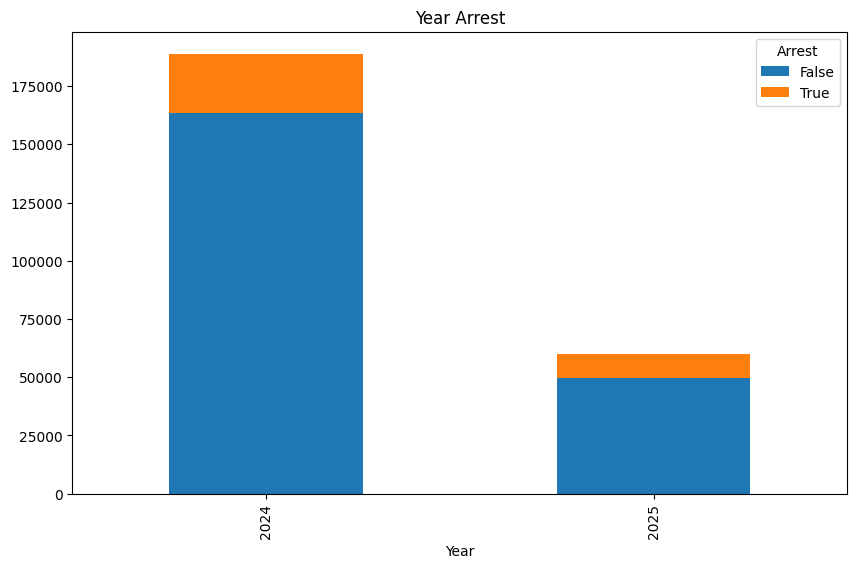

In [19]:
x = crimes.groupby(['Year', 'Arrest']).size().unstack()
x.plot(kind='bar', 
       stacked=True, 
       figsize=(10,6),
      title='Year Arrest')
plt.show()

<h2>INSIGHTS</h2>
<h3>22. Crime reports sharply decreased in 2015 compared to 2014 – total recorded incidents fell by more than half, indicating a major drop in crime or changes in reporting/recording.</h3>
<h3>23. Arrests remain a smaller proportion of total crimes – in both years, non-arrested cases far outnumber arrested ones, showing that many crimes do not result in immediate apprehensions.</h3>
<h3>24. Slightly higher arrest proportion in 2015 – while total cases were fewer, the percentage of arrests relative to incidents appears higher in 2015, suggesting improved enforcement efficiency.</h3>

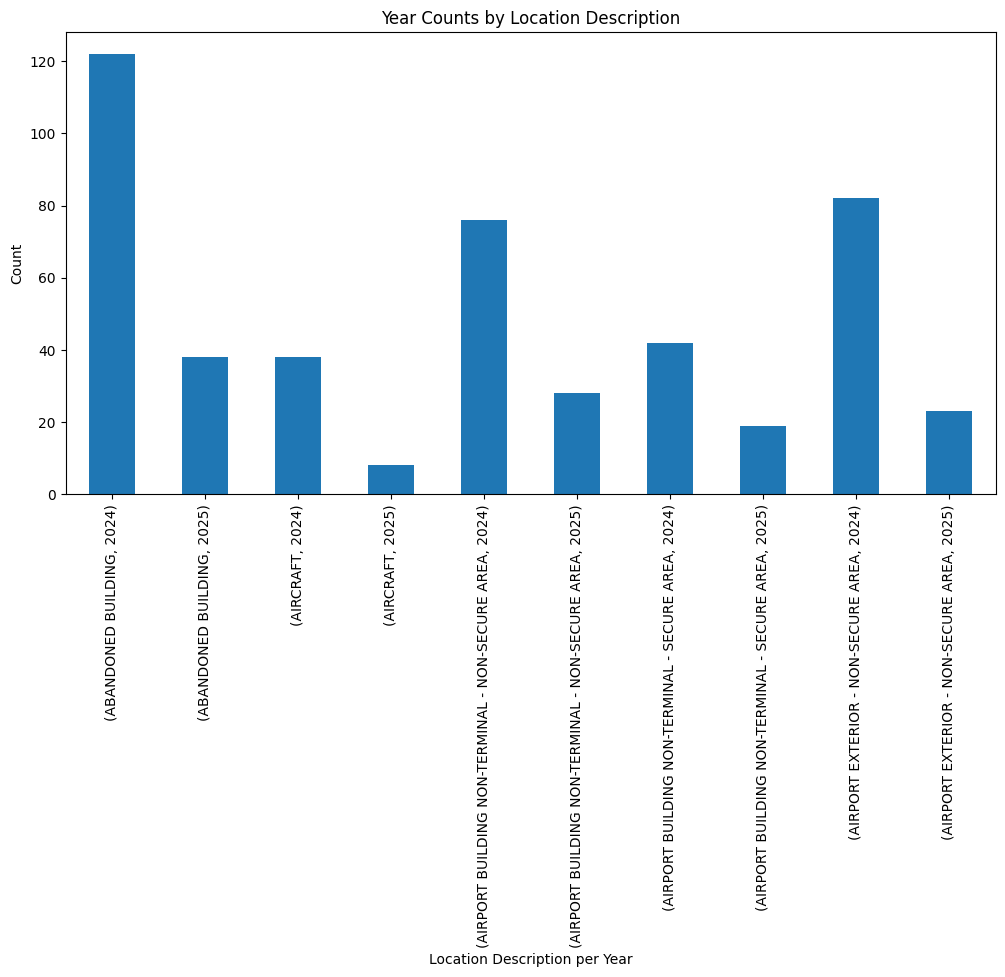

In [20]:
x = crimes.groupby(['Location Description'])['Year'].value_counts().head(10)
x.plot(kind='bar', figsize=(12, 6))
plt.title('Year Counts by Location Description')
plt.xlabel('Location Description per Year')
plt.ylabel('Count')
plt.show()

<h2>INSIGHTS</h2>
<h3>25. Abandoned buildings (2014) had the highest crime count, standing out as the most frequent crime location, which suggests these areas were hotspots for incidents.</h3>
<h3>26. Airport-related areas (secure and non-secure) in both 2014 and 2015 show consistent activity, highlighting that transportation hubs remain sensitive spots for reported crimes.</h3>

In [21]:
crimes5 = crimes[crimes['Primary Type'] == 'DECEPTIVE PRACTICE']

crimes5 = crimes5.groupby(['Latitude','Longitude']).size().reset_index(name='crime_count')

x = folium.Map(location=[41.7958,-87.6232], zoom_start=10)

HeatMap(crimes5).add_to(x)
x

<h2>INSIGHTS</h2>
<h3>27. High-density crime clusters appear along major corridors like Cicero and Central Avenue. These areas likely attract more incidents because they are busy routes with commercial activity and high foot traffic.</h3>
<h3>28. Noticeable hotspots are also forming around transit and rail lines. This suggests transportation hubs may be focal points for criminal activity, possibly due to larger gatherings of people and easier escape routes.</h3>

In [22]:
crimes6 = crimes[crimes['Primary Type'] == 'NON-CRIMINAL']

crimes6 = crimes6.groupby(['Latitude','Longitude']).size().reset_index(name='crime_count')

x = folium.Map(location=[41.7958,-87.6232], zoom_start=10)

HeatMap(crimes6).add_to(x)
x

<h2>INSIGHTS</h2>
<h3>29. Downtown Chicago is a major hotspot for narcotics-related incidents. The central cluster is far denser than surrounding areas, suggesting drug-related activity is concentrated in the urban core where nightlife, street activity, and population density are high.</h3>
<h3>30. Secondary hotspots appear in Evanston (north) and near Hammond (south). These smaller but visible clusters indicate localized narcotics activity outside the central city, possibly tied to suburban transit routes or neighborhood-specific issues.</h3>

In [23]:
crimes7 = crimes[crimes['Primary Type'] == 'STALKING']

crimes7 = crimes7.groupby(['Latitude','Longitude']).size().reset_index(name='crime_count')

x = folium.Map(location=[41.7958,-87.6232], zoom_start=10)

HeatMap(crimes7).add_to(x)
x

<h2>INSIGHTS</h2>
<h3>31. Cases are more dispersed and scattered compared to narcotics or general crimes. Instead of a single dense hotspot, stalking incidents appear across multiple smaller clusters in residential and mixed-use neighborhoods.</h3>
<h3>32. Noticeable clusters appear near parks and along main streets. This suggests stalking cases may be linked to public spaces and high-traffic areas where victims and perpetrators are more likely to cross paths.</h3>

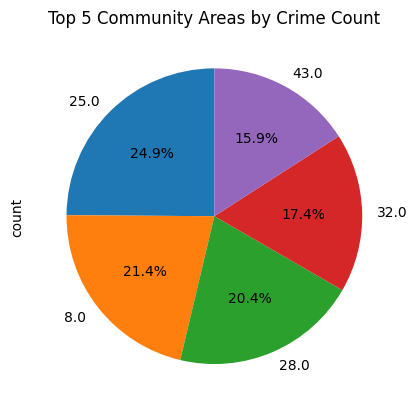

In [24]:
x = crimes['Community Area'].value_counts().head(5)

x.plot(kind='pie',
       autopct='%1.1f%%',
       startangle=90,
       title='Top 5 Community Areas by Crime Count')
plt.show()

<h2>INSIGHTS</h2>
<h3>33. Community Area 25 has the largest crime share (24.9%), making it a key hotspot compared to the other top areas. Focused interventions here could yield significant crime reduction.</h3>
<h3>34. Community Area 43 has the lowest among the top 5 (15.9%), but still stands out enough to be included, indicating it remains a priority zone despite relatively lower counts.</h3>

In [25]:
crimes8 = crimes[crimes['Primary Type'] == 'GAMBLING']

crimes8 = crimes8.groupby(['Latitude','Longitude']).size().reset_index(name='crime_count')

x = folium.Map(location=[41.7958,-87.6232], zoom_start=10)

HeatMap(crimes8).add_to(x)
x

<h2>INSIGHTS</h2>
<h3>35. Downtown Chicago shows the strongest concentration of gambling-related incidents. This aligns with areas of higher nightlife, entertainment, and potential illegal gambling activity.</h3>
<h3>36. Smaller clusters extend southward along major routes. This pattern suggests gambling activity may spread outward from the city center toward nearby communities, possibly tied to transit or local gathering spots.</h3>

In [31]:
list(crimes.columns)

['ID',
 'Case Number',
 'Date',
 'Block',
 'IUCR',
 'Primary Type',
 'Description',
 'Location Description',
 'Arrest',
 'Domestic',
 'Beat',
 'District',
 'Ward',
 'Community Area',
 'FBI Code',
 'X Coordinate',
 'Y Coordinate',
 'Year',
 'Updated On',
 'Latitude',
 'Longitude',
 'Location',
 'Month',
 'Day',
 'DayOfWeek']

In [30]:
crimes['Primary Type'].value_counts()

Primary Type
THEFT                                59201
BATTERY                              44579
CRIMINAL DAMAGE                      27094
ASSAULT                              22615
MOTOR VEHICLE THEFT                  19604
OTHER OFFENSE                        16781
DECEPTIVE PRACTICE                   14991
BURGLARY                              8443
ROBBERY                               8200
WEAPONS VIOLATION                     7164
NARCOTICS                             6627
CRIMINAL TRESPASS                     5045
OFFENSE INVOLVING CHILDREN            1597
CRIMINAL SEXUAL ASSAULT               1573
SEX OFFENSE                           1210
PUBLIC PEACE VIOLATION                1006
INTERFERENCE WITH PUBLIC OFFICER       771
HOMICIDE                               553
STALKING                               520
ARSON                                  452
PROSTITUTION                           287
CONCEALED CARRY LICENSE VIOLATION      249
LIQUOR LAW VIOLATION                   19

In [29]:
crimes['Ward'].value_counts()

Ward
27    11622
28    11013
6      9246
42     8721
24     8686
4      8095
20     8037
17     7914
16     7766
21     7480
9      7399
8      7247
7      7086
37     6940
34     6841
3      6640
5      5638
29     5274
10     5193
1      4521
46     4393
26     4262
44     4218
15     4042
49     4031
2      4014
18     3934
36     3877
32     3861
25     3847
14     3831
48     3499
35     3464
31     3038
11     3026
43     2948
41     2918
22     2916
40     2843
12     2799
13     2796
30     2789
33     2782
50     2649
45     2636
23     2593
47     2561
39     2557
19     2522
38     2118
Name: count, dtype: int64